# Processing

This notebook turns the "Measurements" assignment (Chapter 4) into a runnable, guided pipeline, applied to **your own images**.

It is written as a **generic template**: the same code processes all three flows studied during the lab sessions — a free stream, the wake of a cylinder, and the flow behind a backward-facing step — at the three pump regimes. This is not meant to be a complete overview.

> **About the examples shown below.** This statement was written before any
> student data existed, so the walkthrough is illustrated with a synthetic
> placeholder dataset (`synthetic_piv.py`) — just to orient you towards the
> analyses expected at each step. Set `DATA_SOURCE` to `"real"` in §1 and
> everything below runs the same way on your own images instead; the few places
> marked 🔁 are where real data needs a value you measure yourself rather
> than one we generated.

This builds directly on:

- Chapter 1-2 (cross-correlation, `extended_search_area_piv`)
- Chapter 3 (multi-pass, window deformation, `PIVSettings` / `windef.piv`, vector validation)

In [ ]:
# Standard imports
import pathlib, shutil, time, io, contextlib
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio

from openpiv import tools, windef
from skimage.measure import label, regionprops

@contextlib.contextmanager
def quiet():
    # OpenPIV's windef.piv() is very verbose!
    with contextlib.redirect_stdout(io.StringIO()):
        yield

# synthetic data generator for the examples in this notebook
import sys
sys.path.insert(0, '.')
from synthetic_piv import (
    render_pair, render_sequence, velocity_field, solid_mask,
    reynolds_number, shedding_frequency,
    FLOWS, REGIMES, IMG_SHAPE, CAL, FOV_MM,
    CYL_X_MM, CYL_Y_MM, CYL_D_MM, STEP_X_MM, STEP_H_MM, STEP_LR_MM,
)

np.random.seed(0)
%matplotlib inline


## Dataset

`FLOWS` are the three configurations studied in the lab (`"free"`, `"cylinder"`, `"step"`), each run at three regimes (`"low"`, `"mid"`, `"high"`) corresponding to the three pump settings.

Each sequence of images must sit in
`data/real/<flow>/<regime>/` as a series of `.png` files.

In [ ]:
# ============================================================================
# 🔁 DATA SOURCE -- this is the one switch to flip once your own images are
# ready.
# ============================================================================
DATA_SOURCE = "synthetic"   # "synthetic" or "real"

# 🔁 real only: time between the two consecutive frames.
DT_PIV_REAL = 0.001
DT_FRAME_REAL = {"low": None, "mid": None, "high": None}

N_REALIZATIONS_SYNTHETIC = 10   # only used to generate the synthetic placeholder
DT_PIV_SYNTHETIC = 0.06         # s, only used to generate the synthetic placeholder

# One folder per case: DATA_ROOT/<flow>/<regime>/*.png.
DATA_ROOT = pathlib.Path('data/synthetic' if DATA_SOURCE == "synthetic" else 'data/real')
DT_PIV = DT_PIV_SYNTHETIC if DATA_SOURCE == "synthetic" else DT_PIV_REAL

def frames_of(flow, regime):
    """Image sequence of one case, in natural order."""
    return tools.natural_sort(list((DATA_ROOT / flow / regime).glob('*.png')))

def generate_synthetic_dataset():
    """Write the placeholder sequences: for each case, 2 x N_REALIZATIONS_SYNTHETIC
    frames (A, B, A, B, ...) as DATA_ROOT/<flow>/<regime>/frame_NNNN.png."""
    if DATA_ROOT.exists():
        shutil.rmtree(DATA_ROOT)
    for flow in FLOWS:
        for regime in REGIMES:
            out_dir = DATA_ROOT / flow / regime
            out_dir.mkdir(parents=True)
            rng_seed_base = hash((flow, regime)) % 10_000
            for i in range(N_REALIZATIONS_SYNTHETIC):
                t_sample = np.random.default_rng(rng_seed_base + i).uniform(0, 10)
                a, b, _ = render_pair(flow, regime, t=t_sample, dt=DT_PIV_SYNTHETIC,
                                       seed=rng_seed_base + i)
                iio.imwrite(str(out_dir / f'frame_{2 * i:04d}.png'), a)
                iio.imwrite(str(out_dir / f'frame_{2 * i + 1:04d}.png'), b)


np.random.seed(0)
if DATA_SOURCE == "synthetic":
    generate_synthetic_dataset()

for flow in FLOWS:
    for regime in REGIMES:
        n_frames = len(frames_of(flow, regime))
        if n_frames == 0:
            raise FileNotFoundError(
                f"No .png frames found in {DATA_ROOT / flow / regime}. Convert your "
                f"recorded sequence for this case there first (see the Appendix of Chapter 4)."
            )
        if n_frames % 2:
            raise ValueError(
                f"{DATA_ROOT / flow / regime}: odd number of frames ({n_frames}) -- "
                f"pairing with '(1+2),(3+4)' (§5) needs an even number, remove the extra one."
            )
        print(f"  {flow:10s} {regime:6s} -> {n_frames} frames")

IMAGE_SHAPE = iio.imread(frames_of(FLOWS[0], list(REGIMES)[0])[0]).shape
print(f"image shape: {IMAGE_SHAPE}")

image shape: (192, 384)


In [19]:
print(f"{'flow':10s} {'regime':6s} {'U0 (mm/s)':>10s} {'Re':>8s} {'f_shed (Hz)':>12s}")
for flow in FLOWS:
    for regime in REGIMES:
        U0 = 60.0 * REGIMES[regime]
        f_str = f"{shedding_frequency(regime):.3f}" if flow == 'cylinder' else "-"
        print(f"{flow:10s} {regime:6s} {U0:10.1f} {reynolds_number(flow, regime):8.0f} {f_str:>12s}")


flow       regime  U0 (mm/s)       Re  f_shed (Hz)
free       low          36.0      540            -
free       mid          60.0      900            -
free       high         90.0     1350            -
cylinder   low          36.0      432        0.600
cylinder   mid          60.0      720        1.000
cylinder   high         90.0     1080        1.500
step       low          36.0      540            -
step       mid          60.0      900            -
step       high         90.0     1350            -


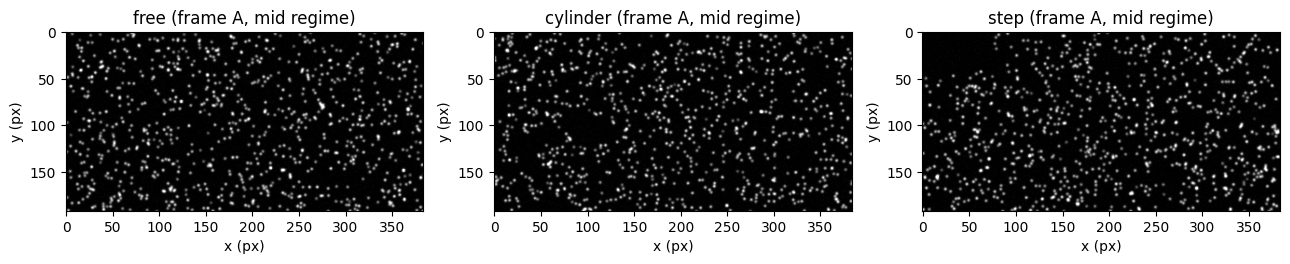

In [20]:
# Preview one image pair per flow (mid regime), straight from disk
fig, axs = plt.subplots(1, 3, figsize=(13, 4))
for ax, flow in zip(axs, FLOWS):
    a = iio.imread(frames_of(flow, 'mid')[0])
    ax.imshow(a, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{flow} (frame A, mid regime)')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
plt.tight_layout()
plt.show()

## Image-quality diagnostics

Following Chapter 4, before running any correlation we look at the raw
images: particle image size, density and grey-level dynamic range. The code
below is the same `regionprops`-based approach, applied here to one of our
synthetic frames — apply it unchanged to a sample of your own images.


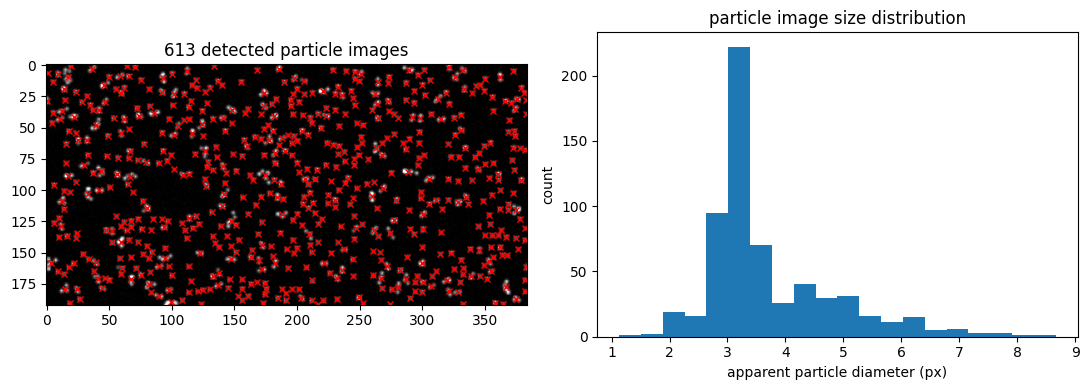

seeding density        : 8.314 10^-3 particles px^2
mean apparent diameter : 3.76 px
dynamic range          : 0 - 255 (8-bit)


In [21]:
sample = iio.imread(frames_of('cylinder', 'mid')[0])

threshold = np.percentile(sample, 90)
binary_img = sample > threshold
label_img = label(binary_img, background=0)
regions = regionprops(label_img, intensity_image=sample)

diam_px = np.array([2 * np.sqrt(r.area / np.pi) for r in regions])
n_particles = len(regions)
density = n_particles / (sample.shape[0] * sample.shape[1])  # particles / px^2

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].imshow(sample, cmap='gray')
for r in regions:
    y0, x0 = r.weighted_centroid
    axs[0].plot(x0, y0, marker='x', color='r', markersize=5)
axs[0].set_title(f'{n_particles} detected particle images')

axs[1].hist(diam_px, bins=20)
axs[1].set_xlabel('apparent particle diameter (px)')
axs[1].set_ylabel('count')
axs[1].set_title('particle image size distribution')
plt.tight_layout()
plt.show()

print(f"seeding density        : {density*1e3:.3f} 10^-3 particles px^2")
print(f"mean apparent diameter : {diam_px.mean():.2f} px")
print(f"dynamic range          : {sample.min()} - {sample.max()} (8-bit)")

> **On real images**, report these numbers for each of your recordings and compare with what you obtained in the theory part.

## Masking

Within an obstacle part of the field of view (cylinder or step): no particles, no valid vectors there. OpenPIV's `windef.PIVSettings.static_mask` accepts a boolean array (`True` = masked) the same size as the images.

On real images, `mask_for(flow)` below reads off the obstacle geometry (here, in mm but can be written in pxl) from a representative frame. `openpiv.preprocess.dynamic_masking` is an alternative if a simple circle/rectangle isn't a good enough fit (worth trying if the parametric mask leaves visible artifacts at the obstacle edge).

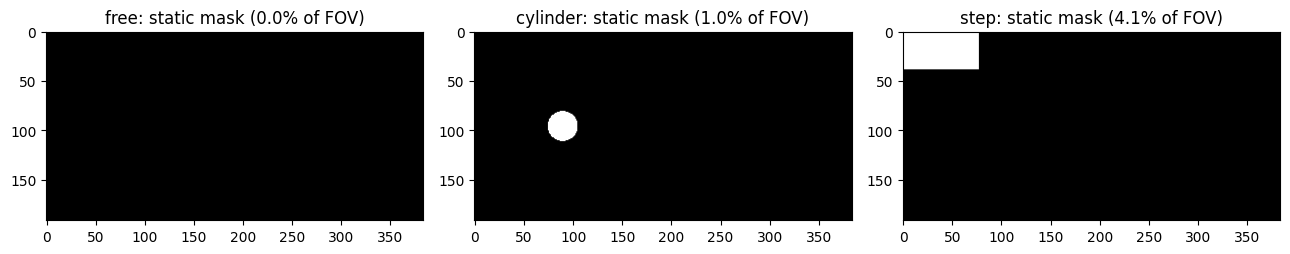

In [23]:
def mask_for(flow):
    ny, nx = IMAGE_SHAPE
    xs_px, ys_px = np.meshgrid(np.arange(nx), np.arange(ny))
    x_mm, y_mm = xs_px / scaling_factor, ys_px / scaling_factor

    if DATA_SOURCE == "synthetic":
        return solid_mask(flow, x_mm, y_mm)

    # 🔁 Real, parametric mask -- fill in from a representative frame (§1/§2):
    if flow == 'cylinder':
        cx_mm, cy_mm, d_mm = 35.0, y_mm.max() / 2, 12.0   # 🔁 centre (x,y), diameter, mm
        return (x_mm - cx_mm) ** 2 + (y_mm - cy_mm) ** 2 < (d_mm / 2) ** 2
    if flow == 'step':
        step_x_mm, step_h_mm = 30.0, 15.0                  # 🔁 step location, height, mm
        return (x_mm < step_x_mm) & (y_mm < step_h_mm)
    return np.zeros((ny, nx), dtype=bool)   # free stream: nothing to mask


fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, flow in zip(axs, FLOWS):
    m = mask_for(flow)
    ax.imshow(m, cmap='gray')
    ax.set_title(f'{flow}: static mask ({m.mean()*100:.1f}% of FOV)')
plt.tight_layout()
plt.show()

## Batch multi-pass processing

We now run the advanced pipeline from Chapter 3 (`PIVSettings` + `windef.piv`) over a **batch of independent realizations** for every flow/regime combination. 

Pairs are built from the sequence with `settings.frame_pattern_b = '(1+2),(3+4)'`
(frames 1+2, then 3+4, ...), as in Chapter 3.

In [ ]:
# Default window (64->32->16 px), to be adapted.
DEFAULT_WINDOWSIZES, DEFAULT_OVERLAP = (64, 32, 16), (32, 16, 8)
WINDOWSIZES = {"step": (48, 24, 12)}
OVERLAP = {"step": (24, 12, 6)}

def windows_for(flow):
    return WINDOWSIZES.get(flow, DEFAULT_WINDOWSIZES), OVERLAP.get(flow, DEFAULT_OVERLAP)

RESULTS_ROOT = pathlib.Path('results')
if RESULTS_ROOT.exists():
    shutil.rmtree(RESULTS_ROOT)

def make_piv_settings(image_dir, save_dir, mask, dt, suffix, windowsizes, overlap,
                       pattern_a='*.png', pattern_b='(1+2),(3+4)'):
    s = windef.PIVSettings()
    s.filepath_images = image_dir
    s.save_path = save_dir
    s.save_folder_suffix = suffix
    s.frame_pattern_a = pattern_a
    s.frame_pattern_b = pattern_b
    s.roi = 'full'
    s.static_mask = mask
    s.windowsizes = windowsizes
    s.overlap = overlap
    s.num_iterations = len(windowsizes)
    s.correlation_method = 'circular'
    s.subpixel_method = 'gaussian'
    s.deformation_method = 'symmetric'
    s.validation_first_pass = True
    s.min_max_u_disp = (-200, 200)
    s.min_max_v_disp = (-200, 200)
    s.std_threshold = 6
    s.median_threshold = 3
    s.sig2noise_threshold = 1.1
    s.replace_vectors = True
    s.smoothn = True
    s.smoothn_p = 0.5
    s.filter_method = 'localmean'
    s.max_filter_iteration = 4
    s.filter_kernel_size = 2
    s.scaling_factor = scaling_factor   # px -> mm
    s.dt = dt
    s.show_plot = False
    s.save_plot = False
    return s

t0 = time.time()
for flow in FLOWS:
    mask = mask_for(flow)
    windowsizes, overlap = windows_for(flow)
    for regime in REGIMES:
        image_dir = DATA_ROOT / flow / regime
        n_pairs = len(frames_of(flow, regime)) // 2

        settings = make_piv_settings(
            image_dir=image_dir,
            save_dir=RESULTS_ROOT / flow / regime,
            mask=mask, dt=DT_PIV, suffix='batch',
            windowsizes=windowsizes, overlap=overlap,
        )
        with quiet():
            windef.piv(settings)
        print(f"  {flow:10s} {regime:6s} -> {n_pairs} pairs processed "
              f"(final window {windowsizes[-1]} px)")

print(f"\nAll flow/regime cases processed in {time.time()-t0:.1f} s")

  free       low    -> 10 pairs processed (final window 16 px)
  free       mid    -> 10 pairs processed (final window 16 px)
  free       high   -> 10 pairs processed (final window 16 px)
  cylinder   low    -> 10 pairs processed (final window 16 px)
  cylinder   mid    -> 10 pairs processed (final window 16 px)
  cylinder   high   -> 10 pairs processed (final window 16 px)
  step       low    -> 10 pairs processed (final window 12 px)
  step       mid    -> 10 pairs processed (final window 12 px)
  step       high   -> 10 pairs processed (final window 12 px)

All flow/regime cases processed in 15.0 s


## Quick quality control

Before moving to the analysis notebook, check how many vectors needed validation/replacement in each case — a first, cheap indicator of where the PIV parameters (window sizes, thresholds) might need adjusting.

In [26]:
def batch_invalid_fraction(flow, regime):
    windowsizes, _ = windows_for(flow)
    folder = RESULTS_ROOT / flow / regime / f'OpenPIV_results_{windowsizes[-1]}_batch'
    fracs = []
    for f in sorted(folder.glob('field_A*.txt')):
        data = np.loadtxt(f, skiprows=1)
        flags = data[:, 4]
        fracs.append(np.mean(flags != 0))
    return np.mean(fracs)

print(f"{'flow':10s} {'regime':6s} {'mean invalid-vector fraction':>28s}")
for flow in FLOWS:
    for regime in REGIMES:
        frac = batch_invalid_fraction(flow, regime)
        print(f"{flow:10s} {regime:6s} {frac*100:27.1f} %")

flow       regime mean invalid-vector fraction
free       low                            0.8 %
free       mid                            1.3 %
free       high                           1.3 %
cylinder   low                            1.1 %
cylinder   mid                            1.7 %
cylinder   high                           2.6 %
step       low                            4.2 %
step       mid                            5.6 %
step       high                           9.4 %


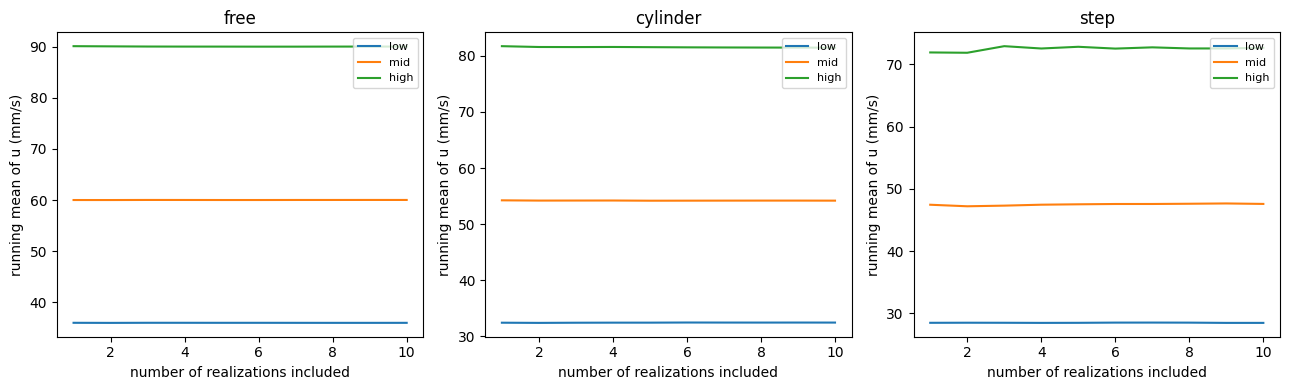

flow       regime    N   last-10% relative change
free       low      10                      0.01%
free       mid      10                      0.00%
free       high     10                      0.00%
cylinder   low      10                      0.01%
cylinder   mid      10                      0.02%
cylinder   high     10                      0.01%
step       low      10                      0.00%
step       mid      10                      0.16%
step       high     10                      0.14%


In [27]:
def convergence_curve(flow, regime):
    """Running mean of the field-averaged streamwise velocity vs. number of
    realizations included, in processing order."""
    import warnings
    windowsizes, _ = windows_for(flow)
    folder = RESULTS_ROOT / flow / regime / f'OpenPIV_results_{windowsizes[-1]}_batch'
    files = sorted(folder.glob('field_A*.txt'))
    Us, running_means = [], []
    for f in files:
        data = np.loadtxt(f, skiprows=1)
        u, mask_ = data[:, 2], data[:, 5]
        u = np.where(mask_ > 0, np.nan, u)
        Us.append(u)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            running_means.append(np.nanmean(np.stack(Us)))
    return np.arange(1, len(files) + 1), np.array(running_means)


fig, axs = plt.subplots(1, len(FLOWS), figsize=(13, 4), sharex=False)
for ax, flow in zip(axs, FLOWS):
    for regime in REGIMES:
        n, running_mean = convergence_curve(flow, regime)
        ax.plot(n, running_mean, label=regime)
    ax.set_xlabel('number of realizations included')
    ax.set_ylabel('running mean of u (mm/s)')
    ax.set_title(flow)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

CONVERGENCE_THRESHOLD = 0.02  # flag if the mean is still moving by more than 2%
                               # of its own value over the last 10% of realizations
print(f"{'flow':10s} {'regime':6s} {'N':>4s} {'last-10% relative change':>26s}")
for flow in FLOWS:
    for regime in REGIMES:
        n, running_mean = convergence_curve(flow, regime)
        if len(n) >= 10:
            tail = max(1, len(n) // 10)
            rel_change = abs(running_mean[-1] - running_mean[-1 - tail]) / (abs(running_mean[-1]) + 1e-9)
            flag = '  <-- consider more realizations in session 2' if rel_change > CONVERGENCE_THRESHOLD else ''
            print(f"{flow:10s} {regime:6s} {len(n):4d} {rel_change*100:25.2f}%{flag}")
        else:
            print(f"{flow:10s} {regime:6s} {len(n):4d} {'(need >= 10 realizations to check)':>26s}")

## Summary & next step

We now have, under `results/<flow>/<regime>/`: `OpenPIV_results_<final window>_batch/field_A0000..NNNN.txt` — one file per realization, ready for statistics (mean, fluctuations, turbulence intensity, ...). 

If you decide in session 2 that a given flow/regime needs more realizations, re-acquire just that case, replace its frames under `data/real/<flow>/<regime>/`, and re-run from §1
onward.